In [ ]:
import micropattern as mic
import scanpy as sc
from pathlib import Path
import numpy as np
import phate
import matplotlib.pyplot as plt

sc.set_figure_params(figsize=(5, 5))

cwd = Path(".").resolve()
print(cwd)

/home/stanfish/Git/micropattern/notebooks


In [279]:
mic.io.fetch_minn_heemskerk_adata_hvg(cwd)
adata_integrate = sc.read_h5ad(cwd / "misc_data" / mic.io.MISC_DATA["minn_heemskerk_adata_hvg"])

100%|██████████| 1/1 [04:14<00:00, 254.12s/it]


In [224]:
# model 4
adata = sc.read_h5ad(cwd / ".." / "tmp" / "model5" / "adata.h5ad")
# adata.obsm["X_umap"] = np.array(adata.obs.loc[:, ["umap_x", "umap_y"]])
sample_to_stage = {
    '48h-1': '48h',
    '48h-2': '48h',
    '72h-1': '72h',
    '72h-2': '72h',
    '96h-1': '96h' ,
    '96h-2': '96h',
    '2020-FC-9000_42h': '42h',
    'BMP4_42h': '42h',
    'GSM4300502_gastruloid1_44h': '44h',
    'GSM4300503_gastruloid2_44h': '44h' ,
    'GSM5176718_gastruloid_0h_1': '0h',
    'GSM5176719_gastruloid_0h_2': '0h' ,
    'GSM5176720_gastruloid_12h_1': '12h',
    'GSM5176721_gastruloid_12h_2': '12h',
    'GSM5176722_gastruloid_24h_1': '12h',
    'GSM5176723_gastruloid_24h_2': '12h',
    'bc_2': '144h' ,
    'bc_3': '192h' ,
    'bc_4': '240h',
}
sample_to_stage_source = {
    '48h-1': 'heemskerk-48h',
    '48h-2': 'heemskerk-48h',
    '72h-1': 'heemskerk-72h',
    '72h-2': 'heemskerk-72h',
    '96h-1': 'heemskerk-96h' ,
    '96h-2': 'heemskerk-96h',
    '2020-FC-9000_42h': 'heemskerk-42h',
    'BMP4_42h': 'heemskerk-42h',
    'GSM4300502_gastruloid1_44h': 'minn-44h',
    'GSM4300503_gastruloid2_44h': 'minn-44h' ,
    'GSM5176718_gastruloid_0h_1': 'minn-0h',
    'GSM5176719_gastruloid_0h_2': 'minn-0h' ,
    'GSM5176720_gastruloid_12h_1': 'minn-12h',
    'GSM5176721_gastruloid_12h_2': 'minn-12h',
    'GSM5176722_gastruloid_24h_1': 'minn-12h',
    'GSM5176723_gastruloid_24h_2': 'minn-12h',
    'bc_2': 'heemskerk-144h' ,
    'bc_3': 'heemskerk-192h' ,
    'bc_4': 'heemskerk-240h',
}
adata.obs["stage"] = adata.obs["sample_labels"].replace(sample_to_stage)
adata.obs["stage_source"] = adata.obs["sample_labels"].replace(sample_to_stage_source)

/tmp/ipykernel_79004/1416649494.py:46: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["stage"] = adata.obs["sample_labels"].replace(sample_to_stage)
/tmp/ipykernel_79004/1416649494.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["stage_source"] = adata.obs["sample_labels"].replace(sample_to_stage_source)


In [225]:
# phate_op = phate.PHATE(knn=10, n_components=3, decay=30, t=35) # for model4
phate_op = phate.PHATE(knn=25, n_components=2, t=33, decay=100)
adata.obsm["X_phate"] = phate_op.fit_transform(adata.obsm["X_scvi"])

Calculating PHATE...
  Running PHATE on 87737 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 4.63 seconds.
    Calculating affinities...
    Calculated affinities in 1.52 seconds.
  Calculated graph and diffusion operator in 6.38 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 12.14 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.01 seconds.
  Calculated landmark operator in 17.15 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.51 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.15 seconds.
Calculated PHATE in 27.46 seconds.


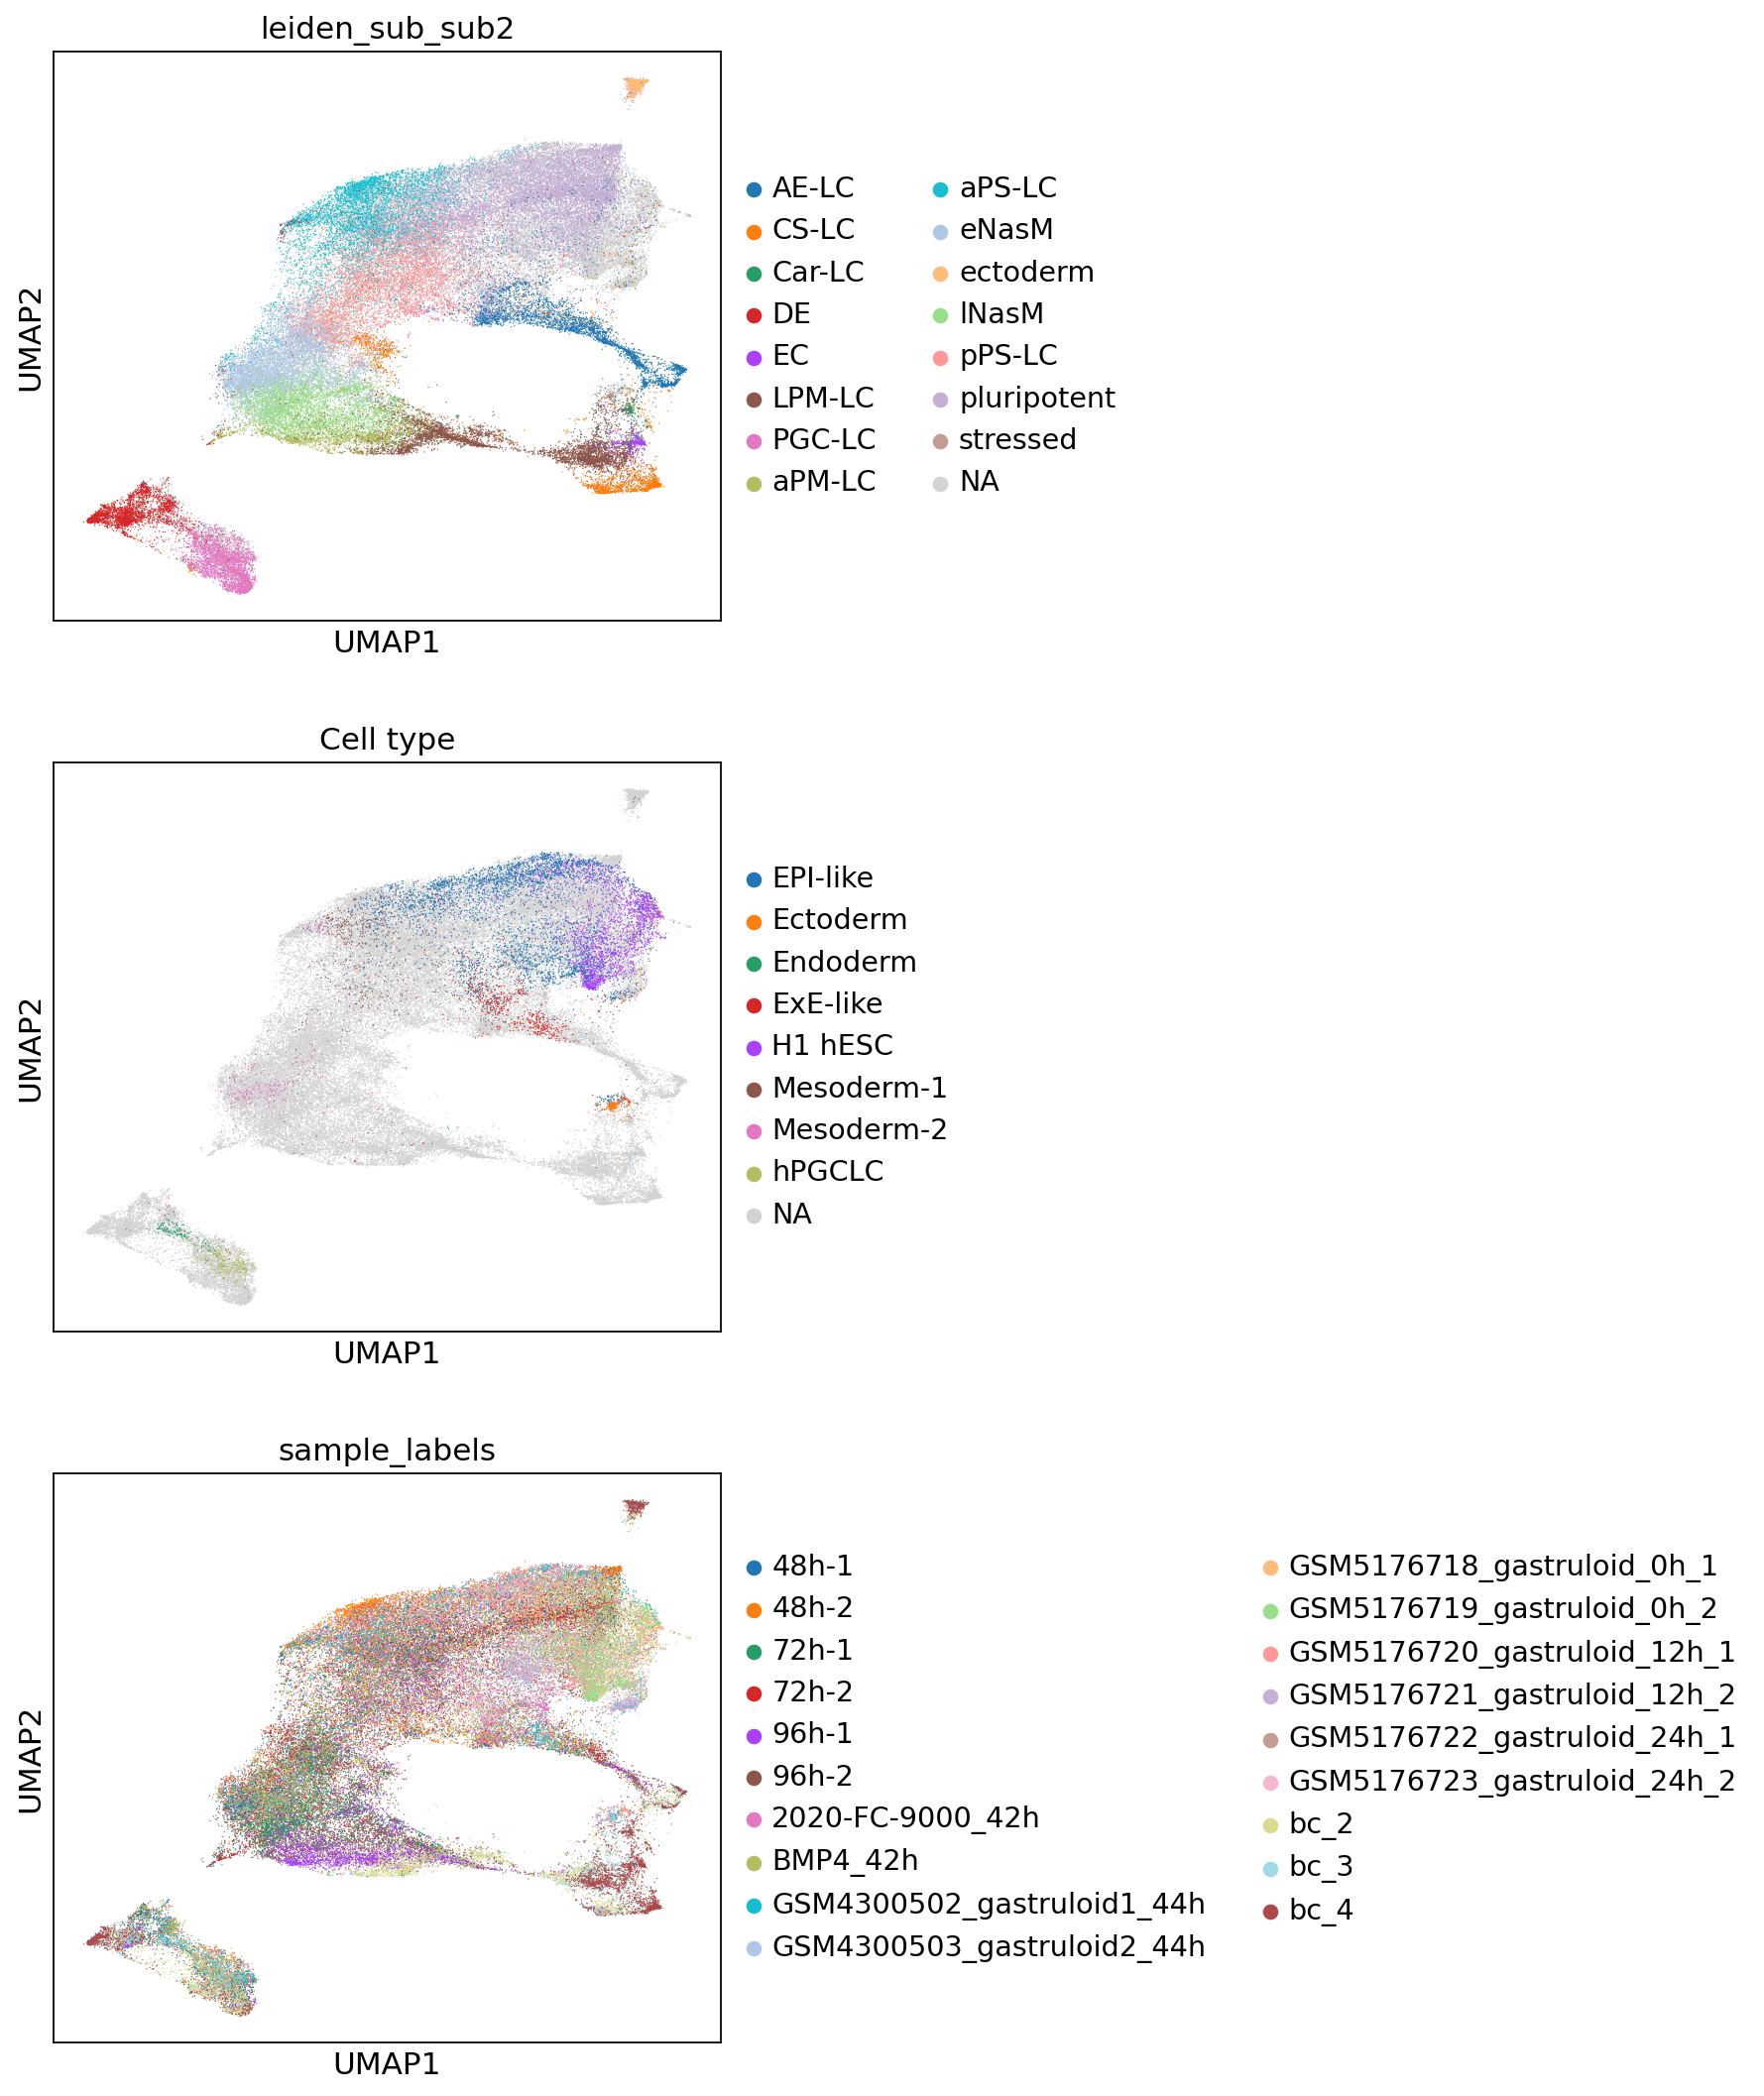

In [252]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_scvi", random_state=0)
sc.tl.umap(adata, min_dist=0.01, random_state=2)
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type", "sample_labels"], ncols=1)

In [300]:
glist = list(adata_integrate.var_names[adata_integrate.var_names.str.contains("VIM |LUM |ANXA1 |DCN")])
print(glist)

['ANXA1 (ENSG00000135046)', 'DCN (ENSG00000011465)', 'LUM (ENSG00000139329)', 'VIM (ENSG00000026025)']


In [240]:
adata.obs["stage_hours"] = adata.obs["stage"].str.replace("h", "").astype(float)
stage_order = ["0h", "12h", "42h", "44h", "48h", "72h", "96h", "144h", "192h", "240h"]
adata.obs["stage"] = adata.obs["stage"].astype("category").cat.set_categories(stage_order, ordered=True)
cmap = plt.get_cmap("viridis")
stage_colors = [cmap(i / (len(stage_order) - 1)) for i in range(len(stage_order))]

stage_source_order = sorted(adata.obs["stage_source"].unique(), 
                           key=lambda x: float(x.split("-")[1].replace("h", "")))
adata.obs["stage_source"] = adata.obs["stage_source"].astype("category").cat.set_categories(stage_source_order, ordered=True)
stage_to_color = {stage: color for stage, color in zip(stage_order, stage_colors)}
stage_source_colors = [stage_to_color[s.split("-")[1]] for s in stage_source_order]

subset = np.where(adata.obs["stage_hours"] <= 999)[0]
np.random.seed(1)
subset = np.random.permutation(subset)

In [284]:
adata_integrate.obsm["X_phate"] = adata.obsm["X_phate"].copy()

In [ ]:
np.random.seed(1)
sort_idx = np.random.permutation(adata.shape[0])
_, axes = plt.subplots(2, 4, figsize=(20, 10))
sc.pl.embedding(
    adata[sort_idx],
    basis="X_umap",
    color=["leiden_sub_sub2"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[0,0],
    frameon=False,
    legend_loc="right",
    title="heemskerk labels (umap)",
)
axes[0,0].legend(ncol=2, bbox_to_anchor=(0.75, 0.5), loc='upper left', frameon=False)

sc.pl.embedding(
    adata[sort_idx],
    basis="X_umap",
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,0],
    frameon=False,
    title="minn labels (umap)",
)
sc.pl.embedding(
    adata[sort_idx][~adata[sort_idx].obs["Cell type"].isna()],
    basis="X_umap",
    color=["Cell type"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,0],
    frameon=False,
    legend_loc="right",
    title="minn labels (umap)",
    size=15
)
axes[1,0].legend(ncol=1, bbox_to_anchor=(0.75, 0.5), loc='upper left', frameon=False)

sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    color=["leiden_sub_sub2"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[0,1],
    frameon=False,
    legend_loc="none",
    title="heemskerk labels (phate)",
)
sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,1],
    frameon=False,
    legend_loc="none",
    title="minn labels (phate)",
)
sc.pl.embedding(
    adata[sort_idx][~adata[sort_idx].obs["Cell type"].isna()],
    basis="X_phate",
    color=["Cell type"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,1],
    frameon=False,
    legend_loc="none",
    title="minn labels (phate)",
    size=15
)
sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    color=["stage_source"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[0,2],
    frameon=False,
    legend_loc="right margin",
    palette="tab10",
    title="stage",
)
axes[0,2].legend(ncol=1, bbox_to_anchor=(-0.25, -0.25), loc='lower left', frameon=False)
sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    color=["stage_source"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,2],
    frameon=False,
    legend_loc="right margin",
    palette=stage_colors,
    title="stage",
)
axes[1,2].legend(ncol=1, bbox_to_anchor=(-0.25, -0.25), loc='lower left', frameon=False)

adata_heemskerk_tmp = adata[sort_idx][adata[sort_idx].obs["stage_source"].str.contains("heemskerk")].copy()
del adata_heemskerk_tmp.uns["stage_source_colors"]
sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[0,3],
    frameon=False,
    legend_loc="none",
    title="minn stage (phate)",
)
sc.pl.embedding(
    adata_heemskerk_tmp,
    basis="X_phate",
    color=["stage_source"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[0,3],
    frameon=False,
    legend_loc="right margin",
    title="heemskerk stage",
)
del adata_heemskerk_tmp

adata_minn_tmp = adata[sort_idx][~adata[sort_idx].obs["Cell type"].isna()].copy()
del adata_minn_tmp.uns["stage_source_colors"]
sc.pl.embedding(
    adata[sort_idx],
    basis="X_phate",
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,3],
    frameon=False,
    legend_loc="none",
    title="heemskerk stage",
)
sc.pl.embedding(
    adata_minn_tmp,
    basis="X_phate",
    color=["stage_source"],
    components=["0,1"],
    na_in_legend=False,
    show=False,
    ax=axes[1,3],
    frameon=False,
    legend_loc="right margin",
    title="minn stage",
    size=15,
)
del adata_minn_tmp
plt.savefig("micropattern.png", dpi=300, bbox_inches="tight")

/home/stanfish/Git/micropattern/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/home/stanfish/Git/micropattern/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


[<Axes: title={'center': 'ANXA1 (ENSG00000135046)'}, xlabel='X_phate0', ylabel='X_phate1'>,
 <Axes: title={'center': 'DCN (ENSG00000011465)'}, xlabel='X_phate0', ylabel='X_phate1'>,
 <Axes: title={'center': 'LUM (ENSG00000139329)'}, xlabel='X_phate0', ylabel='X_phate1'>,
 <Axes: title={'center': 'VIM (ENSG00000026025)'}, xlabel='X_phate0', ylabel='X_phate1'>]

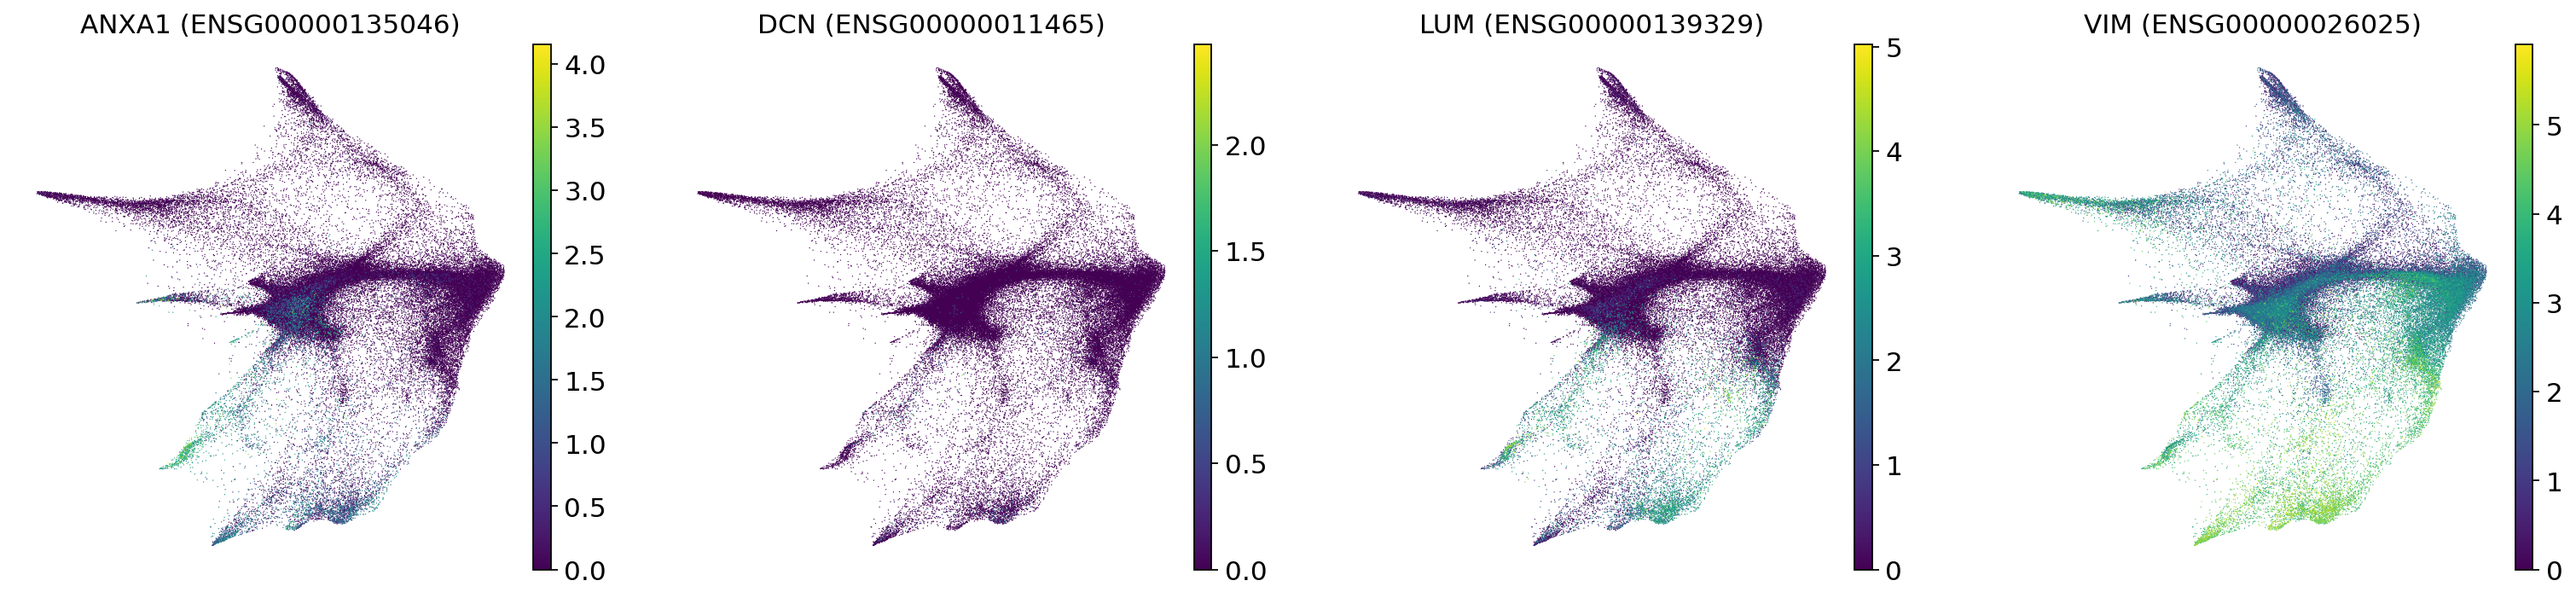

In [301]:
np.random.seed(1)
sort_idx = np.random.permutation(adata.shape[0])
sc.pl.embedding(
    adata_integrate[sort_idx],
    basis="X_phate",
    color=glist,
    components=["0,1"],
    na_in_legend=False,
    show=False,
    frameon=False,
)